In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv


### Preprocessing

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv")
df = df.dropna(subset=["statement", "status"]).drop_duplicates()

le = LabelEncoder()
df["label"] = le.fit_transform(df["status"])
num_labels = df["label"].nunique()

# Divisione del Dataset in train e validation
train_df, val_df = train_test_split(
    df, test_size=0.15, stratify=df["label"], random_state=42
)

In [3]:
# Stampa metriche dei Datafarme creati

print(f"Train DataFrame size: {train_df.shape}")
print(f"Train DataFrame samples:\n {train_df.head()}")
print(f"\nVal DataFrame size: {val_df.shape}")
print(f"Val DataFrame samples:\n {val_df.head()}")

Train DataFrame size: (44778, 4)
Train DataFrame samples:
        Unnamed: 0                                          statement  \
42636       42636                                     congested nose   
15210       15210  Please anyone who has been in the same situati...   
43578       43578  yopatrizzle not sure to tell u the truth it s ...   
7224         7224  I went to my psych about a week or so ago for ...   
14506       14506  I am not sure why, but i feel empty and discon...   

           status  label  
42636      Normal      3  
15210  Depression      2  
43578      Normal      3  
7224   Depression      2  
14506  Depression      2  

Val DataFrame size: (7903, 4)
Val DataFrame samples:
        Unnamed: 0                                          statement  \
7486         7486  I do not know how else to say this. My air con...   
51809       51809  crippling guilt from my inability to answer te...   
23780       23780  Therapy is moving slowly because I cannot fuck...   
105

### Creazione Dataset da CSV

In [4]:
from transformers import AutoTokenizer
from datasets import Dataset

# Recupero del tokenizer del modello da usare
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Funzione per tokenizzare un batch testuale 
def tokenize(batch):
    return tokenizer(batch["statement"], truncation=True, padding="max_length", max_length=256)

# Applicazione del tokenizer ai dataset train e validation
train_ds = Dataset.from_pandas(train_df[["statement", "label"]]).map(tokenize, batched=True)
val_ds = Dataset.from_pandas(val_df[["statement", "label"]]).map(tokenize, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/44778 [00:00<?, ? examples/s]

Map:   0%|          | 0/7903 [00:00<?, ? examples/s]

In [5]:
# Stampa delle dimensioni dei dataset dopo l'applicazione del tokenizer

print(f"Train Dataset size: {train_ds.shape}")
print(f"Train Dataset sample:\n {train_ds[0]}")
print(f"Val Dataset size: {val_ds.shape}")
print(f"Val Dataset sample:\n {val_ds[0]}")

Train Dataset size: (44778, 6)
Train Dataset sample:
 {'statement': 'congested nose', 'label': 3, '__index_level_0__': 42636, 'input_ids': [101, 26478, 17944, 4451, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [6]:
from transformers import AutoModelForSequenceClassification

# Caricamento pesi del modello pre-trainato e aggiunta di un layer Head non addestrato per la classificazione 
# (num_labels indica i nodi finali della classificazione)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=num_labels
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Calcolo delle metriche di valutazione partendo dalle predizioni
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# Argomenti per il train
args = TrainingArguments(
    output_dir="./results", # Cartella dove salvare checkpoint e logs
    eval_strategy="epoch", # modello valutato sul validation set alla fine di ogni epoca
    save_strategy="epoch", # modello salvato dopo ogni epoca
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3, # numero di passaggi completi sull'intero training set
    weight_decay=0.01,
    load_best_model_at_end=True, # vengono caricati i pesi del checkpoint con prestazioni migliori
    metric_for_best_model="f1_macro", # metrica da usare per la valutazione del miglior checkpoint
    fp16=True,  # abilita il training in mixed precision (calcoli in float16 invece di float32 dove possibile)
)

# Creazione dell'oggetto Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

# Addestramento (Fine-tuning) del modello
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.049828,0.960513,0.805770,0.784113
2,0.785889,0.838820,0.829432,0.810181


### Caricamento modello migliore salvato

In [5]:
import os, json
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset

# -------------------------------------------------------------------
# 1. Legge trainer_state.json dall'ultimo checkpoint (è cumulativo)
# -------------------------------------------------------------------
# Il file nell'ultimo checkpoint contiene già tutta la cronologia
# del training e il campo best_model_checkpoint aggiornato,
# quindi non serve leggere i file dei checkpoint precedenti.

last_checkpoint  = "./results/checkpoint-4200"
state_path       = os.path.join(last_checkpoint, "trainer_state.json")

with open(state_path, "r") as f:
    trainer_state = json.load(f)

# Stampa la cronologia completa per verifica
print("=== Cronologia valutazioni ===")
for entry in trainer_state["log_history"]:
    if "eval_f1_macro" in entry:
        print(f"  Step {entry['step']:>5} | "
              f"eval_loss: {entry['eval_loss']:.4f} | "
              f"f1_macro: {entry['eval_f1_macro']:.4f} | "
              f"accuracy: {entry['eval_accuracy']:.4f}")

best_checkpoint = trainer_state["best_model_checkpoint"]
best_metric     = trainer_state["best_metric"]
print(f"\nMiglior checkpoint: {best_checkpoint}")
print(f"Miglior f1_macro:   {best_metric:.4f}")

# -------------------------------------------------------------------
# 2. Carica tokenizer e modello dal checkpoint migliore
# -------------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(best_checkpoint)
model     = AutoModelForSequenceClassification.from_pretrained(best_checkpoint)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print(f"\nModello caricato su: {device}")
print(f"Numero classi: {model.config.num_labels}")

# -------------------------------------------------------------------
# 3. Ricostruisce LabelEncoder e val_df
# -------------------------------------------------------------------

df = pd.read_csv("/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv")
df = df.dropna(subset=["statement", "status"]).drop_duplicates()

le = LabelEncoder()
df["label"] = le.fit_transform(df["status"])

print(f"\nClassi del LabelEncoder: {list(le.classes_)}")

train_df, val_df = train_test_split(
    df, test_size=0.15, stratify=df["label"], random_state=42
)

#train_df = train_df.reset_index(drop=True)
#val_df   = val_df.reset_index(drop=True)

print(f"Dimensione validation set: {len(val_df)} esempi")

# -------------------------------------------------------------------
# 4. Ricostruisce val_ds tokenizzato per il DataLoader
# -------------------------------------------------------------------

def tokenize(batch):
    return tokenizer(batch["statement"], truncation=True, padding="max_length", max_length=256)

val_ds = Dataset.from_pandas(val_df[["statement", "label"]]).map(tokenize, batched=True)

print("\nDataset tokenizzato correttamente.")
print("Tutto pronto — puoi eseguire le celle di valutazione.")

=== Cronologia valutazioni ===
  Step  1400 | eval_loss: 0.9605 | f1_macro: 0.7841 | accuracy: 0.8058
  Step  2800 | eval_loss: 0.8388 | f1_macro: 0.8102 | accuracy: 0.8294
  Step  4200 | eval_loss: 0.8200 | f1_macro: 0.8225 | accuracy: 0.8369

Miglior checkpoint: ./results/checkpoint-4200
Miglior f1_macro:   0.8225


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Modello caricato su: cuda
Numero classi: 7

Classi del LabelEncoder: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
Dimensione validation set: 7903 esempi


Map:   0%|          | 0/7903 [00:00<?, ? examples/s]


Dataset tokenizzato correttamente.
Tutto pronto — puoi eseguire le celle di valutazione.


### Stampa prestazioni modello

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

             Anxiety       0.00      0.00      0.00       576
             Bipolar       0.00      0.00      0.00       417
          Depression       0.00      0.00      0.00      2311
              Normal       0.31      1.00      0.47      2452
Personality disorder       0.00      0.00      0.00       161
              Stress       0.00      0.00      0.00       388
            Suicidal       0.00      0.00      0.00      1598

            accuracy                           0.31      7903
           macro avg       0.04      0.14      0.07      7903
        weighted avg       0.10      0.31      0.15      7903



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


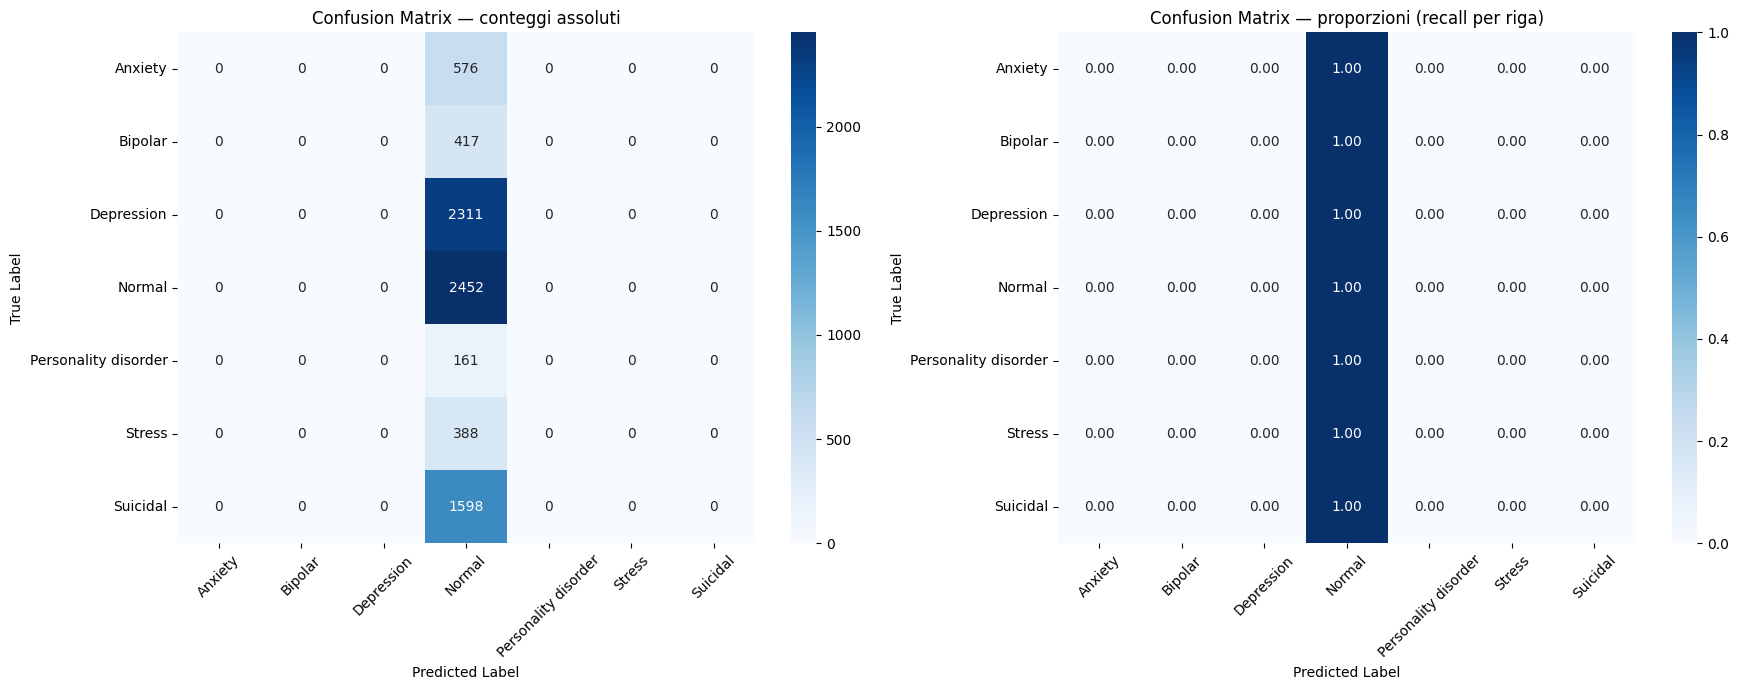

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
import torch

# Metti il modello in modalità inferenza
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Prepara il validation set come tensori PyTorch
# Rimuove la colonna "statement" (stringa, non convertibile in tensore)
val_ds_torch = val_ds.remove_columns(["statement"])
val_ds_torch.set_format("torch")

loader = DataLoader(val_ds_torch, batch_size=32)

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].cpu().numpy()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds   = probs.argmax(axis=1)

        all_preds.extend(preds)
        all_labels.extend(labels)
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# --- Classification report ---
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# --- Confusion matrix normalizzata ---
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizza per riga

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sinistra: conteggi assoluti
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title("Confusion Matrix — conteggi assoluti")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")
axes[0].tick_params(axis="x", rotation=45)

# Destra: proporzioni per riga (recall per-classe sulla diagonale)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title("Confusion Matrix — proporzioni (recall per riga)")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Stampa di esempi di testo classificato erroneamente

In [ ]:
import pandas as pd

val_texts = val_df["statement"].reset_index(drop=True).values

wrong_mask = all_preds != all_labels

failures_df = pd.DataFrame({
    "text"       : val_texts[wrong_mask],
    "true_label" : le.inverse_transform(all_labels[wrong_mask]),
    "pred_label" : le.inverse_transform(all_preds[wrong_mask]),
    "confidence" : all_probs[wrong_mask].max(axis=1)
}).sort_values("confidence", ascending=False).reset_index(drop=True)

print(f"Esempi classificati male: {wrong_mask.sum()} / {len(all_labels)} "
      f"({100 * wrong_mask.mean():.1f}%)\n")

# Top 10 errori ad alta confidenza: il modello era "sicuro" ma sbagliava
print("=" * 60)
print("TOP 10 HIGH-CONFIDENCE FAILURES")
print("Casi in cui il modello sbagliava con maggiore certezza")
print("=" * 60)
for _, row in failures_df.head(10).iterrows():
    print(f"\nTESTO   : {row['text'][:250]}")
    print(f"CORRETTA: {row['true_label']:<25} PREDETTA: {row['pred_label']:<25} CONFIDENZA: {row['confidence']:.1%}")
    print("-" * 60)

# Analisi degli errori: quali coppie (vera, predetta) sono più frequenti
print("\n=== Coppie di errore più frequenti ===")
print(failures_df.groupby(["true_label", "pred_label"])
      .size()
      .sort_values(ascending=False)
      .head(10)
      .to_string())

### Explainability del modello

In [ ]:
!pip install lime --quiet

from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import torch

# Funzione che LIME chiama internamente: data una lista di testi,
# restituisce una matrice [n_testi x n_classi] di probabilità.
# LIME perturba il testo originale (rimuove parole a caso) per capire
# quali contribuiscono di più alla predizione.
def predict_proba_fn(texts):
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    return torch.softmax(outputs.logits, dim=1).cpu().numpy()

lime_explainer = LimeTextExplainer(class_names=le.classes_)

# Seleziona esempi interessanti da spiegare:
# - 2 predizioni corrette (una per classe "facile", una per classe rara)
# - 2 high-confidence failures (già trovati nella cella precedente)
correct_mask = all_preds == all_labels
correct_texts  = val_texts[correct_mask]
correct_labels = all_labels[correct_mask]

examples_to_explain = [
    # (testo, etichetta_vera, descrizione)
    (correct_texts[0],
     le.inverse_transform([correct_labels[0]])[0],
     "CORRETTA — esempio classificato bene"),

    (correct_texts[5],
     le.inverse_transform([correct_labels[5]])[0],
     "CORRETTA — secondo esempio"),

    (failures_df.iloc[0]["text"],
     failures_df.iloc[0]["true_label"],
     f"FALLIMENTO — vera: {failures_df.iloc[0]['true_label']}, "
     f"predetta: {failures_df.iloc[0]['pred_label']}"),

    (failures_df.iloc[1]["text"],
     failures_df.iloc[1]["true_label"],
     f"FALLIMENTO — vera: {failures_df.iloc[1]['true_label']}, "
     f"predetta: {failures_df.iloc[1]['pred_label']}"),
]

for text, true_label, description in examples_to_explain:
    print("\n" + "=" * 70)
    print(f"  {description}")
    print(f"  ETICHETTA VERA: {true_label}")
    print(f"  TESTO: {text[:200]}")
    print("=" * 70)

    # num_features: quante parole vengono mostrate nel grafico
    # num_samples: quante perturbazioni LIME genera per stimare i contributi
    #              (più alto = più preciso, ma più lento)
    exp = lime_explainer.explain_instance(
        text,
        predict_proba_fn,
        num_features=12,
        num_samples=500,
        top_labels=3      # mostra la spiegazione per le 3 classi più probabili
    )

    pred_idx = predict_proba_fn([text]).argmax()
    pred_label = le.classes_[pred_idx]

    print(f"\n  PREDIZIONE: {pred_label}")
    print(f"\n  Parole più influenti per la classe predetta '{pred_label}':")

    # Stampa testuale delle feature più importanti
    for word, weight in exp.as_list(label=pred_idx):
        direction = "▲ AUMENTA prob." if weight > 0 else "▼ RIDUCE prob."
        print(f"    {word:<20} {direction}  ({weight:+.4f})")

    # Visualizzazione grafica
    fig = exp.as_pyplot_figure(label=pred_idx)
    fig.set_size_inches(10, 5)
    plt.title(f"LIME — Classe predetta: '{pred_label}' | Vera: '{true_label}'", fontsize=13)
    plt.tight_layout()
    plt.show()